# 01 — Exploratory Data Analysis
Understand the raw datasets before any modelling.

In [4]:
!pip install pandas
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 749.3 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.1 MB 979.3 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.1 MB 979.3 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#050a0f'
matplotlib.rcParams['axes.facecolor']   = '#0a1520'
matplotlib.rcParams['text.color']       = '#d0e8e0'
matplotlib.rcParams['axes.labelcolor']  = '#7a9e90'
matplotlib.rcParams['xtick.color']      = '#3a5e50'
matplotlib.rcParams['ytick.color']      = '#3a5e50'
print("Imports OK")

Imports OK


## 1. Load raw data

In [6]:
from src.data_loader import load_jhu_cases, load_jhu_deaths, load_owid

cases  = load_jhu_cases(download=True)
deaths = load_jhu_deaths(download=True)
owid   = load_owid(download=True)

print("Cases shape: ", cases.shape)
print("Deaths shape:", deaths.shape)
print("OWID shape:  ", owid.shape)
cases.head()

  Found cached: jhu_confirmed.csv


d:\Projects\EpiTrack\epidemic-spread-prediction\src\data_loader.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby('Country/Region').sum(numeric_only=True).reset_index()
d:\Projects\EpiTrack\epidemic-spread-prediction\src\data_loader.py:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


  Found cached: jhu_deaths.csv


d:\Projects\EpiTrack\epidemic-spread-prediction\src\data_loader.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby('Country/Region').sum(numeric_only=True).reset_index()
d:\Projects\EpiTrack\epidemic-spread-prediction\src\data_loader.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


  Found cached: owid-covid-data.csv
Cases shape:  (229743, 3)
Deaths shape: (229743, 3)
OWID shape:   (417680, 11)


,country,date,confirmed_cumulative
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0


## 2. Date range & country count

In [7]:
print(f"Date range: {cases.date.min()} → {cases.date.max()}")
print(f"Countries : {cases.country.nunique()}")

Date range: 2020-01-22 00:00:00 → 2023-03-09 00:00:00
Countries : 201


## 3. Top 10 countries by total cases

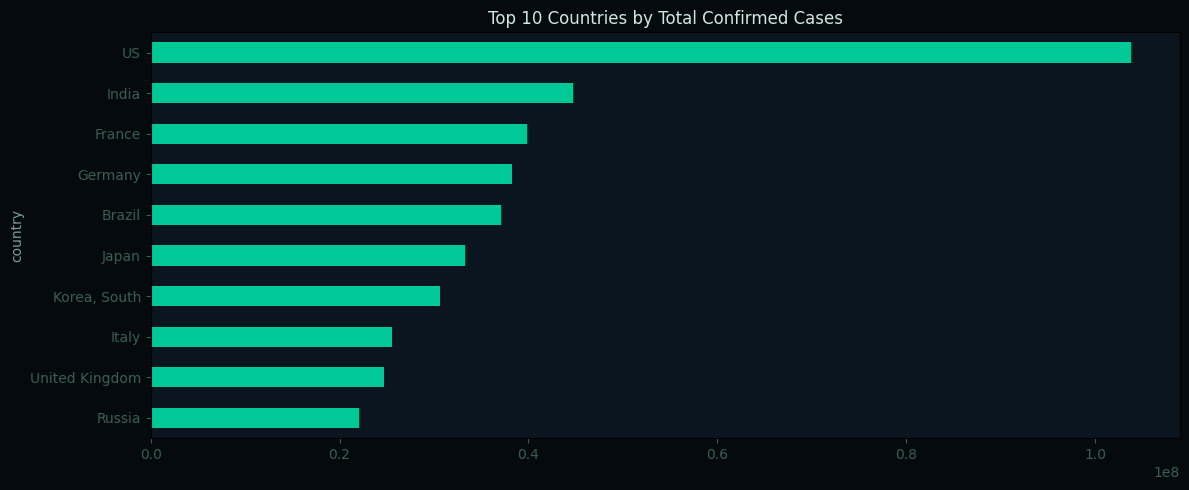

In [8]:
top10 = (cases.groupby('country')['confirmed_cumulative']
         .max().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 5))
top10.plot(kind='barh', ax=ax, color='#00c896')
ax.set_title('Top 10 Countries by Total Confirmed Cases', color='#d0e8e0')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Time-series for selected countries

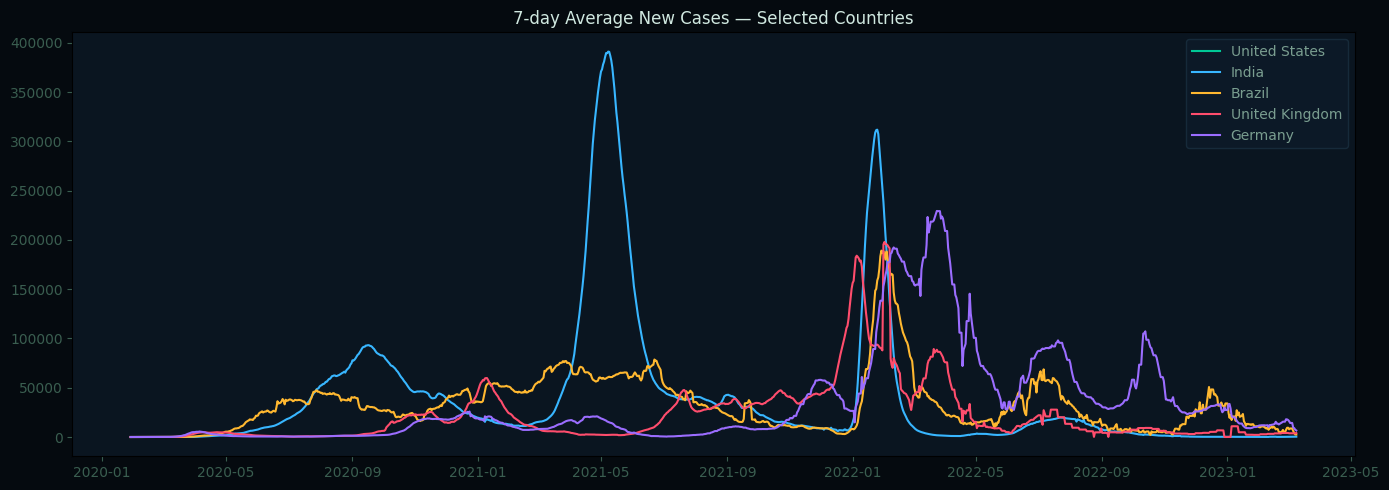

In [9]:
countries = ['United States','India','Brazil','United Kingdom','Germany']
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#00c896','#38b6ff','#ffb830','#ff4d6d','#9b6dff']

for c, col in zip(countries, colors):
    sub = cases[cases.country == c].sort_values('date')
    # daily new
    sub = sub.copy()
    sub['new'] = sub['confirmed_cumulative'].diff().clip(lower=0)
    sub['new7'] = sub['new'].rolling(7).mean()
    ax.plot(sub['date'], sub['new7'], label=c, color=col, linewidth=1.5)

ax.set_title('7-day Average New Cases — Selected Countries', color='#d0e8e0')
ax.legend(facecolor='#0d1b2a', edgecolor='#1a3040', labelcolor='#7a9e90')
plt.tight_layout()
plt.show()

## 5. Missing value analysis (OWID)

In [10]:
missing = (owid.isnull().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0].to_string())

people_fully_vaccinated_per_hundred    83.415055
new_tests_per_thousand                 81.947184
total_vaccinations_per_hundred         81.672572
stringency_index                       53.028634
hospital_beds_per_thousand             30.807077
median_age                             20.278922
population_density                     14.095001
life_expectancy                         6.958676


## 6. Correlation heatmap (OWID numeric features)

In [12]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


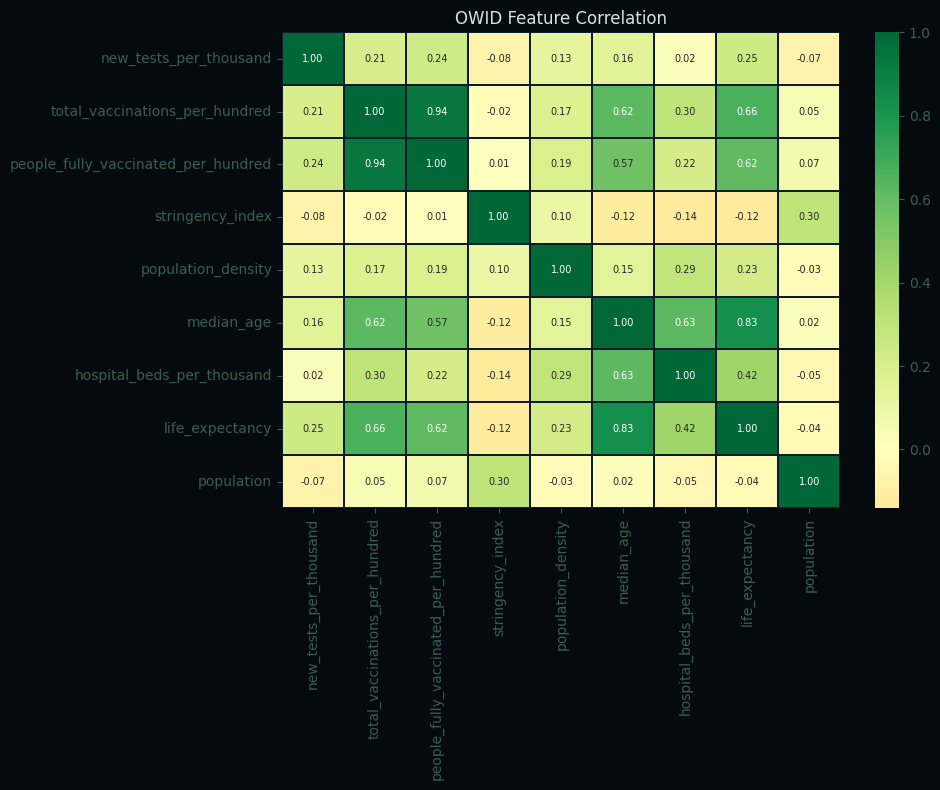

In [13]:
import seaborn as sns

# Take latest row per country
latest = owid.sort_values('date').groupby('country').last().reset_index()
num_cols = latest.select_dtypes(include='number').columns.tolist()
corr = latest[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, cmap='RdYlGn', center=0,
            linewidths=0.3, linecolor='#0d1b2a',
            annot=True, fmt='.2f', annot_kws={'size': 7})
ax.set_title('OWID Feature Correlation', color='#d0e8e0')
plt.tight_layout()
plt.show()